In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("employee_data_10000.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,56,Yes,Travel_Rarely,1393,Research & Development,17,4,Other,1,1,...,2,80,0,30,1,2,4,4,4,0
1,46,No,Travel_Rarely,860,Research & Development,20,3,Other,1,2,...,3,80,3,25,4,3,14,14,0,14
2,32,No,Travel_Rarely,472,Sales,1,2,Marketing,1,3,...,2,80,3,25,4,4,25,12,14,2
3,60,No,Travel_Rarely,400,Research & Development,11,5,Other,1,4,...,3,80,2,5,4,1,5,5,4,5
4,25,No,Travel_Frequently,890,Research & Development,11,4,Technical Degree,1,5,...,4,80,0,4,3,2,4,4,4,4


In [3]:
df.shape

(10000, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       10000 non-null  int64 
 1   Attrition                 10000 non-null  object
 2   BusinessTravel            10000 non-null  object
 3   DailyRate                 10000 non-null  int64 
 4   Department                10000 non-null  object
 5   DistanceFromHome          10000 non-null  int64 
 6   Education                 10000 non-null  int64 
 7   EducationField            10000 non-null  object
 8   EmployeeCount             10000 non-null  int64 
 9   EmployeeNumber            10000 non-null  int64 
 10  EnvironmentSatisfaction   10000 non-null  int64 
 11  Gender                    10000 non-null  object
 12  HourlyRate                10000 non-null  int64 
 13  JobInvolvement            10000 non-null  int64 
 14  JobLevel               

In [5]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
df = df.drop(
    ["EmployeeNumber","EmployeeCount","Over18","StandardHours"],
    axis=1,
    errors="ignore"
)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,56,Yes,Travel_Rarely,1393,Research & Development,17,4,Other,4,Male,...,3,2,0,30,1,2,4,4,4,0
1,46,No,Travel_Rarely,860,Research & Development,20,3,Other,4,Male,...,3,3,3,25,4,3,14,14,0,14
2,32,No,Travel_Rarely,472,Sales,1,2,Marketing,1,Male,...,3,2,3,25,4,4,25,12,14,2
3,60,No,Travel_Rarely,400,Research & Development,11,5,Other,3,Female,...,3,3,2,5,4,1,5,5,4,5
4,25,No,Travel_Frequently,890,Research & Development,11,4,Technical Degree,4,Male,...,4,4,0,4,3,2,4,4,4,4


In [8]:
df["Attrition"].value_counts()

Attrition
No     7012
Yes    2988
Name: count, dtype: int64

In [9]:
df["Attrition"] = df["Attrition"].map({"Yes":1,"No":0})

df["Attrition"].value_counts()

Attrition
0    7012
1    2988
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,56,1,2,1393,1,17,4,4,4,1,...,3,2,0,30,1,2,4,4,4,0
1,46,0,2,860,1,20,3,4,4,1,...,3,3,3,25,4,3,14,14,0,14
2,32,0,2,472,2,1,2,2,1,1,...,3,2,3,25,4,4,25,12,14,2
3,60,0,2,400,1,11,5,4,3,0,...,3,3,2,5,4,1,5,5,4,5
4,25,0,1,890,1,11,4,5,4,1,...,4,4,0,4,3,2,4,4,4,4


In [11]:
import pandas as pd

In [12]:
df = pd.read_csv("employee_data_10000.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,56,Yes,Travel_Rarely,1393,Research & Development,17,4,Other,1,1,...,2,80,0,30,1,2,4,4,4,0
1,46,No,Travel_Rarely,860,Research & Development,20,3,Other,1,2,...,3,80,3,25,4,3,14,14,0,14
2,32,No,Travel_Rarely,472,Sales,1,2,Marketing,1,3,...,2,80,3,25,4,4,25,12,14,2
3,60,No,Travel_Rarely,400,Research & Development,11,5,Other,1,4,...,3,80,2,5,4,1,5,5,4,5
4,25,No,Travel_Frequently,890,Research & Development,11,4,Technical Degree,1,5,...,4,80,0,4,3,2,4,4,4,4


In [13]:
df["Attrition"].unique()

array(['Yes', 'No'], dtype=object)

In [14]:
df["Attrition"] = df["Attrition"].map({"No":0, "Yes":1})

df["Attrition"].value_counts()

Attrition
0    7012
1    2988
Name: count, dtype: int64

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,56,1,2,1393,1,17,4,4,1,1,...,2,80,0,30,1,2,4,4,4,0
1,46,0,2,860,1,20,3,4,1,2,...,3,80,3,25,4,3,14,14,0,14
2,32,0,2,472,2,1,2,2,1,3,...,2,80,3,25,4,4,25,12,14,2
3,60,0,2,400,1,11,5,4,1,4,...,3,80,2,5,4,1,5,5,4,5
4,25,0,1,890,1,11,4,5,1,5,...,4,80,0,4,3,2,4,4,4,4


In [16]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print(X.shape)
print(y.shape)

(10000, 34)
(10000,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 34)
(2000, 34)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [20]:
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Scale the data (Logistic Regression needs this to perform well)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize the model
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

# 3. FIT (Train) the model on the scaled training data
lr.fit(X_train_scaled, y_train)

# 4. Now you can safely predict! (Make sure to predict on the scaled test data)
y_pred_lr = lr.predict(X_test_scaled)

In [22]:
y_pred_lr = lr.predict(X_test)
y_pred_lr

array([0, 0, 0, ..., 0, 1, 0], shape=(2000,))

In [23]:
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [24]:
y_pred_dt = dt.predict(X_test)
y_pred_dt

array([0, 0, 0, ..., 1, 1, 1], shape=(2000,))

In [25]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
y_pred_rf = rf.predict(X_test)
y_pred_rf

array([0, 0, 0, ..., 0, 1, 0], shape=(2000,))

In [27]:
from sklearn.metrics import accuracy_score

In [28]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.6555
Decision Tree Accuracy: 0.632
Random Forest Accuracy: 0.7285


In [29]:
from sklearn.metrics import confusion_matrix, classification_report

In [30]:
confusion_matrix(y_test, y_pred_lr)

array([[935, 487],
       [202, 376]])

In [31]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.66      0.73      1422
           1       0.44      0.65      0.52       578

    accuracy                           0.66      2000
   macro avg       0.63      0.65      0.63      2000
weighted avg       0.71      0.66      0.67      2000



In [32]:
confusion_matrix(y_test, y_pred_rf)

array([[1377,   45],
       [ 498,   80]])

In [33]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.73      0.97      0.84      1422
           1       0.64      0.14      0.23       578

    accuracy                           0.73      2000
   macro avg       0.69      0.55      0.53      2000
weighted avg       0.71      0.73      0.66      2000



In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

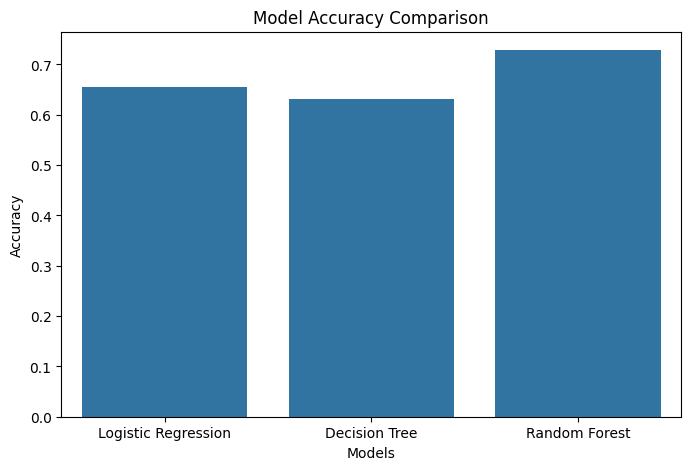

In [35]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()

In [36]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

MonthlyIncome        0.062971
MonthlyRate          0.055195
EmployeeNumber       0.054392
DailyRate            0.053454
HourlyRate           0.049546
TotalWorkingYears    0.046514
DistanceFromHome     0.046158
Age                  0.044509
YearsAtCompany       0.041390
PercentSalaryHike    0.037492
dtype: float64

In [37]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

MonthlyIncome        0.062971
MonthlyRate          0.055195
EmployeeNumber       0.054392
DailyRate            0.053454
HourlyRate           0.049546
TotalWorkingYears    0.046514
DistanceFromHome     0.046158
Age                  0.044509
YearsAtCompany       0.041390
PercentSalaryHike    0.037492
dtype: float64

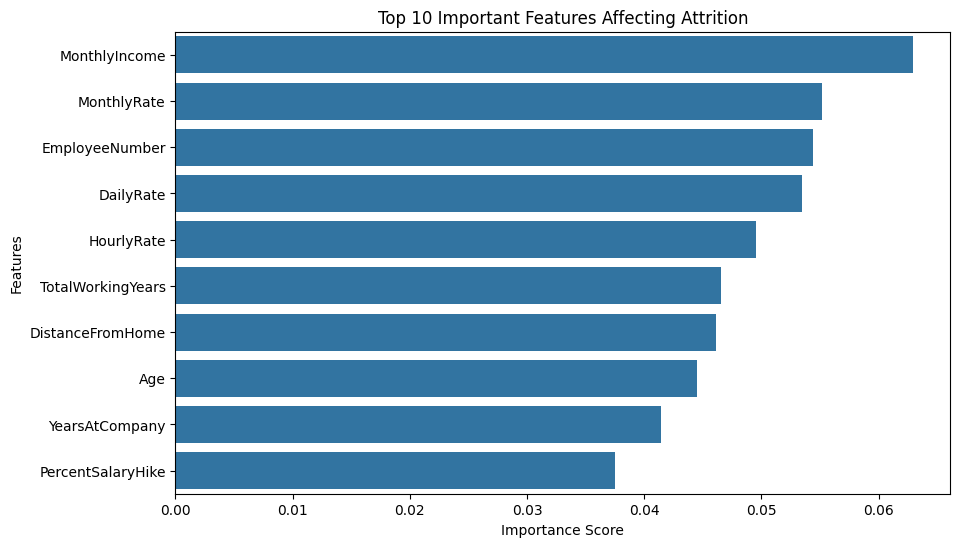

In [38]:
top_features = feature_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)

plt.title("Top 10 Important Features Affecting Attrition")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [39]:
def predict_attrition(input_data):
    prediction = rf.predict([input_data])
    
    if prediction[0] == 1:
        return "Employee likely to leave"
    else:
        return "Employee likely to stay"

In [40]:
corr = df.corr(numeric_only=True)
corr

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,-0.021766,0.007368,-0.011495,-0.001680,-0.008491,0.002812,0.000940,NaN,-0.006100,...,-0.001566,NaN,0.010187,0.020225,0.003904,0.010340,0.009429,-0.009425,0.007231,0.012351
Attrition,-0.021766,1.000000,-0.021648,0.009053,-0.022366,0.053806,-0.006315,0.003554,NaN,-0.005600,...,-0.027195,NaN,-0.107425,-0.071010,-0.002413,-0.098246,-0.070574,-0.042389,0.016428,-0.036974
BusinessTravel,0.007368,-0.021648,1.000000,-0.008007,0.017183,-0.011234,-0.000531,0.013086,NaN,0.002844,...,0.004789,NaN,-0.013204,-0.000433,0.004311,0.010469,-0.005093,-0.000718,-0.020771,0.002628
DailyRate,-0.011495,0.009053,-0.008007,1.000000,0.016842,-0.003748,-0.010300,0.011013,NaN,-0.021225,...,0.006407,NaN,-0.006544,-0.002160,0.010301,-0.008421,-0.010237,-0.001308,0.007019,0.000036
Department,-0.001680,-0.022366,0.017183,0.016842,1.000000,-0.005351,-0.003178,-0.011290,NaN,-0.016326,...,-0.001711,NaN,-0.003159,0.010594,-0.013164,-0.013781,0.016230,-0.004922,0.000987,0.004507
DistanceFromHome,-0.008491,0.053806,-0.011234,-0.003748,-0.005351,1.000000,0.006129,-0.011765,NaN,-0.003706,...,-0.013494,NaN,0.008814,0.011593,-0.005661,-0.013245,0.015952,0.005429,-0.000914,0.008858
Education,0.002812,-0.006315,-0.000531,-0.010300,-0.003178,0.006129,1.000000,-0.008872,NaN,-0.006458,...,0.006169,NaN,0.004756,0.013547,0.020504,0.017484,0.006650,0.006959,-0.004340,-0.008548
EducationField,0.000940,0.003554,0.013086,0.011013,-0.011290,-0.011765,-0.008872,1.000000,NaN,0.021954,...,0.014462,NaN,-0.002326,-0.017567,0.010708,0.003895,-0.008677,0.005677,-0.007474,0.007350
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.006100,-0.005600,0.002844,-0.021225,-0.016326,-0.003706,-0.006458,0.021954,NaN,1.000000,...,0.005863,NaN,-0.018410,-0.008411,-0.001540,-0.001631,-0.012781,-0.007171,-0.016644,-0.000642


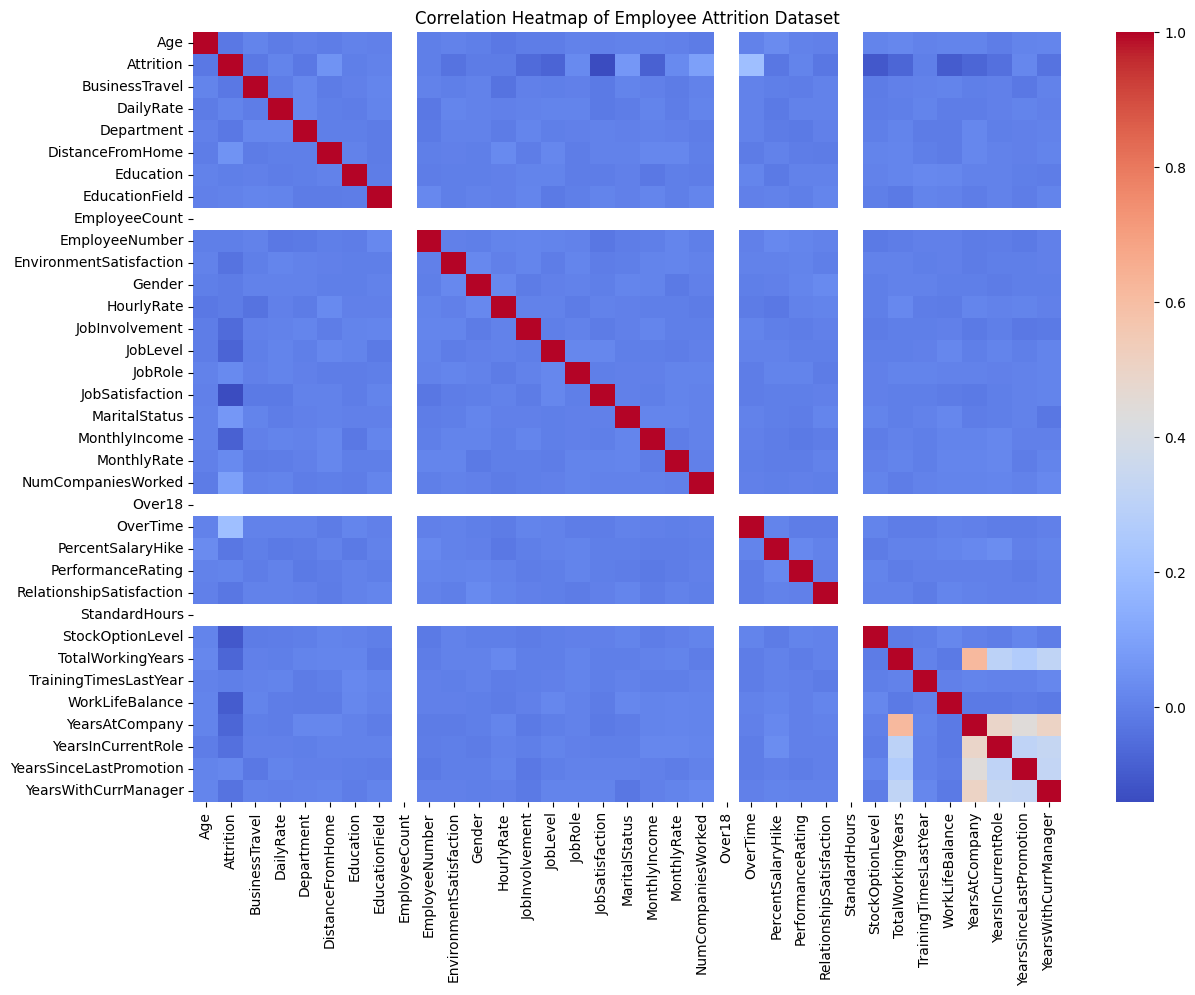

In [41]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', annot=False)

plt.title("Correlation Heatmap of Employee Attrition Dataset")
plt.show()

In [42]:
import joblib

joblib.dump(rf, "attrition_model.pkl")

['attrition_model.pkl']

In [43]:
loaded_model = joblib.load("attrition_model.pkl")

In [44]:
sample = X_test[5]
prediction = loaded_model.predict([sample])

if prediction[0] == 1:
    print("Employee likely to leave")
else:
    print("Employee likely to stay")

Employee likely to stay


In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

In [46]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.7013314012624162


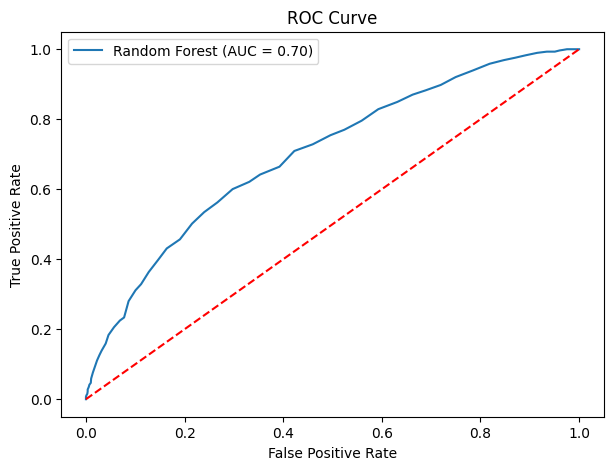

In [47]:
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % auc_score)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

In [48]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.7095 0.719  0.719  0.7225 0.7175]
Average CV Score: 0.7175


In [49]:
print("Employee Attrition Prediction Project Completed Successfully")

print("Best Model: Random Forest")

print("Model Accuracy:", accuracy_score(y_test, y_pred_rf))

print("AUC Score:", auc_score)

print("Cross Validation Score:", scores.mean())

Employee Attrition Prediction Project Completed Successfully
Best Model: Random Forest
Model Accuracy: 0.7285
AUC Score: 0.7013314012624162
Cross Validation Score: 0.7175
